<a href="https://colab.research.google.com/github/dositadi/beures_housing/blob/main/buenos_aires_real_estate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from glob import glob
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


# 1. Import and merge multiple glob files

In [ ]:
# file name pattern
pattern = "/content/drive/MyDrive/world_quant/phase2/buenos-aires-real-estate-*.csv"

In [ ]:
# write a merged files function that merges all the files in the glob (this is for reusability sake)

def merged_files(pattern: str) -> pd.DataFrame:
  return pd.concat([pd.read_csv(path) for path in glob(pattern)],ignore_index=True)

In [ ]:
# get all the file path that satisfy the pattern and read them storing them in the df
df = merged_files(pattern=pattern)

print(f"Dataframe shape: {df.shape}")
print()
df.head()

Dataframe shape: (43029, 16)



,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...
1,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|La Matanza...,NaN,250000.0,USD,3790600.0,250000.0,117.0,120.0,2136.752137,2083.333333,NaN,4.0,NaN,http://ramos-mejia.properati.com.ar/s7pd_venta...
2,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Morón|Cast...,"-34.6497002,-58.658073",410000.0,USD,6216584.0,410000.0,410.0,220.0,1000.000000,1863.636364,NaN,NaN,NaN,http://castelar-moron.properati.com.ar/11vgn_v...
3,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Tres de Fe...,"-34.5957086,-58.5669503",180000.0,USD,2729232.0,180000.0,200.0,135.0,900.000000,1333.333333,NaN,5.0,NaN,http://tres-de-febrero.properati.com.ar/7f7u_v...
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43029 entries, 0 to 43028
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   43029 non-null  object 
 1   property_type               43029 non-null  object 
 2   place_with_parent_names     43029 non-null  object 
 3   lat-lon                     34734 non-null  object 
 4   price                       38073 non-null  float64
 5   currency                    38072 non-null  object 
 6   price_aprox_local_currency  38073 non-null  float64
 7   price_aprox_usd             38073 non-null  float64
 8   surface_total_in_m2         29871 non-null  float64
 9   surface_covered_in_m2       36420 non-null  float64
 10  price_usd_per_m2            24449 non-null  float64
 11  price_per_m2                32642 non-null  float64
 12  floor                       6505 non-null   float64
 13  rooms                       238

# 2. Data Cleaning

**Problem:**

  Market heterogeneity — listings span multiple property types and cities

- **Effect on model if ignored:**

  Regression coefficients bend toward extreme cases, reducing accuracy for typical properties

- **Solution:**

  Filter to Capital Federal Only: The raw dataset spans Capital Federal (the autonomous city of Buenos Aires) and Greater Buenos Aires (GBA) — two fundamentally different real estate markets (Urban and suburban) that should not be modeled together.

  Apartments only: houses and commercial spaces follow different pricing mechanics (lot size, zoning, business revenue potential)

  Price < $400,000: caps the range to typical residential buyers, excluding luxury outliers whose prices are driven by factors our features do not capture

In [ ]:
# write a reusable function to filter and keep only Capital Federal apartments under $400K
def filter_data(dataframe: pd.DataFrame) -> pd.DataFrame:
  return (
      dataframe
      .loc[lambda df: df['place_with_parent_names']
           .str.contains('Capital Federal')]
      .loc[lambda df: df['property_type'] == "apartment"]
      .loc[lambda df: df['price_aprox_usd'] < 400_000]
  )
filter_data(df).head()

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...
11,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6050060697,-58.4001162302",60000.0,USD,909744.0,60000.0,28.0,28.0,2142.857143,2142.857143,NaN,1.0,NaN,http://once.properati.com.ar/zz0q_venta_depart...
20,sell,apartment,|Argentina|Capital Federal|San Nicolás|,"-34.603898,-58.378617",69000.0,USD,1046205.6,69000.0,NaN,22.0,NaN,3136.363636,23.0,2.0,NaN,http://san-nicolas.properati.com.ar/rnju_venta...


# Handling Outliers

Even within Capital Federal apartments under $400K, the surface area column (surface_covered_in_m2) still contains extreme values that would distort the model's learned coefficients.

**Why outliers harm linear regression — the intuition**

Linear regression minimizes the sum of squared errors (SSE). Because errors are squared, a prediction that is 100 units off contributes 10,000 to the SSE, while a prediction that is 10 units off contributes only 100. A single extreme outlier can dominate the entire optimization — the model bends its coefficients to better accommodate that one extreme point, at the cost of accuracy for the thousands of typical properties.


In [ ]:
# write a reusable function to handle the outlier using the quantile based approach
def outlier_df(outlier_data: pd.DataFrame) -> pd.DataFrame:
  return (outlier_data.loc[lambda df: df['surface_covered_in_m2'].between(df['surface_covered_in_m2'].quantile(0.1), df['surface_covered_in_m2'].quantile(0.9))])

check_outliers = outlier_df(df)
check_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29247 entries, 0 to 43028
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   29247 non-null  object 
 1   property_type               29247 non-null  object 
 2   place_with_parent_names     29247 non-null  object 
 3   lat-lon                     23338 non-null  object 
 4   price                       26963 non-null  float64
 5   currency                    26962 non-null  object 
 6   price_aprox_local_currency  26963 non-null  float64
 7   price_aprox_usd             26963 non-null  float64
 8   surface_total_in_m2         22538 non-null  float64
 9   surface_covered_in_m2       29247 non-null  float64
 10  price_usd_per_m2            18931 non-null  float64
 11  price_per_m2                26962 non-null  float64
 12  floor                       5441 non-null   float64
 13  rooms                       18480 no

# Extracting Features from String Columns

Our dataset contains two columns that store multiple pieces of information bundled into a single string. A machine learning model cannot work with strings directly — we need to extract the numeric and categorical information encoded inside them.

In [ ]:
# write a reusable function for feature engineering
def modify_col(dataframe: pd.DataFrame) -> pd.DataFrame:
  return (
      dataframe.assign(
          lat = lambda df:
            df['lat-lon'].str.split(',',expand=True)[0].astype(np.float64),
          lon = lambda df:
            df['lat-lon'].str.split(',',expand=True)[1].astype(np.float64),
          neighbourhood = lambda df:
            df['place_with_parent_names'].str.split('|', expand=True)[3]
      )
  )

check_col = modify_col(df)
check_col.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43029 entries, 0 to 43028
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   43029 non-null  object 
 1   property_type               43029 non-null  object 
 2   place_with_parent_names     43029 non-null  object 
 3   lat-lon                     34734 non-null  object 
 4   price                       38073 non-null  float64
 5   currency                    38072 non-null  object 
 6   price_aprox_local_currency  38073 non-null  float64
 7   price_aprox_usd             38073 non-null  float64
 8   surface_total_in_m2         29871 non-null  float64
 9   surface_covered_in_m2       36420 non-null  float64
 10  price_usd_per_m2            24449 non-null  float64
 11  price_per_m2                32642 non-null  float64
 12  floor                       6505 non-null   float64
 13  rooms                       238

### 2.4 Missing Values Analysis

After filtering, outlier removal, and feature extraction, we need to understand where our data has gaps. Missing values in machine learning are not just an inconvenience — they require a deliberate decision for each affected column.

**The three options for handling missing values:**

| Option | When to use it | Risk |
|--------|---------------|------|
| **Imputation** (fill with mean, median, mode) | Missingness rate is low (<15%) and the column is important | Invented data adds noise; can distort model training if overused |
| **Model-based imputation** | Feature is valuable and pattern of missingness is predictable | Complex to implement correctly; can leak information |
| **Drop the column** | Missingness rate is high (>50%) | Loses potentially useful information, but avoids inventing data for the majority of rows |

**Our approach:** Visualize first, decide second. Two complementary plots reveal both the *magnitude* of missingness (how many values are missing per column?) and the *pattern* (do rows tend to be missing multiple columns together?).

> 🔍 **Why does the pattern matter?**
>
> If `currency`, `price_aprox_local_currency`, and `price_aprox_usd` are always missing together, they share the same source — likely listings that did not record price information at all. Imputing one while keeping the others would create a logically inconsistent record.
#### Understanding *co-occurrence* of missingness guides better decisions.

,0
operation,0.000000
property_type,0.000000
place_with_parent_names,0.000000
properati_url,0.000000
price_aprox_usd,11.517814
price_aprox_local_currency,11.517814
price,11.517814
currency,11.520138
surface_covered_in_m2,15.359409
lat-lon,19.277696


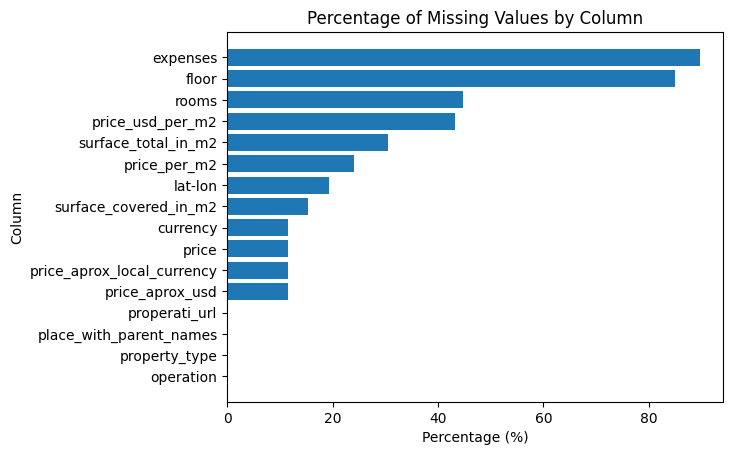

In [ ]:
# Visualizing the missing data using horizontal bar plot
import matplotlib.pyplot as plt

# step 1
# Calculate the percentage of missing values for each column in the dataframe
nan_values_percentage = (
    df.isna().sum() * 100 / len(df)
).sort_values()

display(nan_values_percentage)

fig, ax = plt.subplots()

ax.barh(y=nan_values_percentage.index,width=nan_values_percentage)
ax.set_title('Percentage of Missing Values by Column')
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Column')

fig.show()

/usr/local/lib/python3.13/dist-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


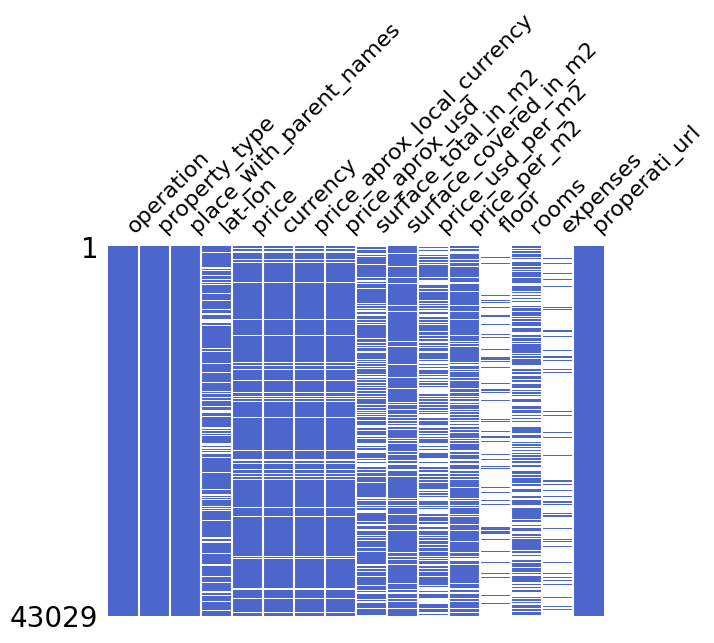

In [ ]:
#  missing value matrix from the missingno library — a more granular view that reveals not just how much is missing, but which rows are missing values across multiple columns simultaneously.
import missingno as msno

fig, ax = plt.subplots()
msno.matrix(df, color=(0.3, 0.4, 0.8),ax=ax)
fig.show()

# Multicollinearity Analysis
Multicollinearity occurs when two or more features in the dataset are highly correlated with each other — they move together almost perfectly, conveying the same underlying information.

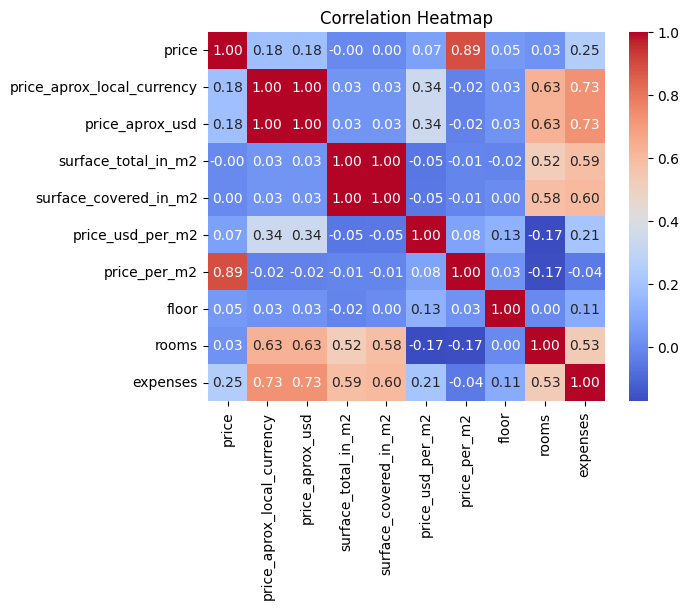

In [ ]:
# plotting a heatmap to visualize the correlation between pair columns
import seaborn as sns

pair_corr = df.select_dtypes("number").corr()
pair_corr_filtered= filter_data(df).select_dtypes("number").corr()

fig, ax = plt.subplots()

sns.heatmap(pair_corr_filtered,annot=True,fmt=".2f",ax=ax,cmap='coolwarm')
ax.set_title("Correlation Heatmap")

fig.show()

### 2.6 Dropping Unnecessary Columns

Based on the missing value analysis and the multicollinearity heatmap, we now have a principled list of columns to remove. Each drop has a specific reason — this is not arbitrary data reduction.

> **Principled Column Removal — Full Rationale**
>
> | Category | Columns | Why they must go |
> |----------|---------|-----------------|
> | **High missingness (>50%)** | `expenses`, `floor`, `rooms` | Imputing >50% of values creates more fictional data than real; any model trained on them would learn noise |
> | **Data leakage** | `price`, `price_aprox_local_currency`, `price_usd_per_m2`, `price_per_m2` | These columns are **computed from the target price**. If left in, the model learns to predict price by reading price — achieving perfect training accuracy but being completely useless on new listings where these derived columns do not exist |
> | **Multicollinearity** | `surface_total_in_m2` | Correlation >0.9 with `surface_covered_in_m2` — keeping both makes both coefficients unstable and uninterpretable |
> | **Unique identifiers** | `properati_url` | Every listing has a unique URL — the model would memorize specific URLs rather than learning generalizable price patterns. A 0% test-set accuracy waiting to happen |
> | **Already extracted** | `lat-lon`, `place_with_parent_names` | We extracted `lat`, `lon`, and `neighborhood` from these — the original string columns are now redundant |
> | **Single-value columns** | `operation`, `property_type`, `currency` | We filtered to one value of each (`"sell"`, `"apartment"`, `"USD"`). A column with zero variance provides zero information to the model |

> ❗️ **Data leakage deserves special emphasis.** It is the most dangerous category because it produces results that look excellent during development — the model seems to perform perfectly — but fail catastrophically when deployed. A real estate platform cannot include `price_usd_per_m2` in a new listing before it has been sold. If the model depends on that column, it is not predicting the price; it is reading it. Always ask: *"Would this feature be available at prediction time?"*


In [ ]:
# Desision: keep price_approx_usd column and drop all other price-related and high-missingness columns

# Final master function to clean the entire dataset
def clean_files(pattern: str) -> pd.DataFrame:
  ''' Final master function to clean the entire dataset '''
  drop_cols = [
    "lat-lon", "place_with_parent_names",
    "floor", "expenses", "rooms", "price",
    "price_aprox_local_currency", "price_usd_per_m2",
    "price_per_m2", "operation", "property_type", "currency",
    "properati_url", "surface_total_in_m2"
  ]

  return (
      merged_files(pattern)
      .pipe(filter_data)
      .pipe(outlier_df)
      .pipe(modify_col)
      .drop(columns=drop_cols)
      .dropna()
  )

In [ ]:
cleaned_df = clean_files(pattern)
cleaned_df.info()
cleaned_df

<class 'pandas.core.frame.DataFrame'>
Index: 6247 entries, 4 to 43021
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6247 non-null   float64
 1   surface_covered_in_m2  6247 non-null   float64
 2   lat                    6247 non-null   float64
 3   lon                    6247 non-null   float64
 4   neighbourhood          6247 non-null   object 
dtypes: float64(4), object(1)
memory usage: 292.8+ KB


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighbourhood
4,129000.0,70.0,-34.584651,-58.454693,Chacarita
9,87000.0,42.0,-34.638979,-58.500115,Villa Luro
29,118000.0,54.0,-34.615847,-58.459957,Caballito
40,57000.0,42.0,-34.625222,-58.382382,Constitución
41,90000.0,50.0,-34.610610,-58.412511,Once
...,...,...,...,...,...
42990,290000.0,83.0,-34.639528,-58.519666,Liniers
42997,150000.0,45.0,-34.597825,-58.416439,Palermo
43001,65000.0,42.0,-34.652233,-58.490739,Mataderos
43002,91440.0,48.0,-34.648761,-58.500180,Mataderos


# Linear Regression model

# Split Data into Features and

The X/y Convention

This separation mirrors the mathematical notation of supervised learning. Every scikit-learn model expects:

X — the feature matrix: a 2D array where rows are observations (individual apartments) and columns are features (measurable characteristics used to predict price). We use uppercase X because it represents a 2-dimensional matrix.

y — the target vector: a 1D array containing the value we want to predict — price_aprox_usd. We use lowercase y because it is a 1-dimensional vector (one number per row).

The correct sequence: clean data → X/y split → train-test split → encoding (inside the pipeline, fit on training only).

In [ ]:
# Splitting the datasets using the X/y convention

target = "price_aprox_usd"
features = [cols for cols in cleaned_df.columns if cols not in [target]]

X = cleaned_df[features]
y = cleaned_df[target]

print(f"X_shape: {X.shape}")
print(f"y_shape: {y.shape}")

X_shape: (6247, 4)
y_shape: (6247,)


# Performing train-test split for one column at a time to understand the entire process.

In [ ]:
X_ = cleaned_df[['surface_covered_in_m2']]
y_ = cleaned_df['price_aprox_usd']

print(f"X_ shape: {X_.shape}")
print(f"y_ shape: {y_.shape}")

X_ shape: (6247, 1)
y_ shape: (6247,)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_, y_, test_size=0.2,random_state=42)

print(f"len(X_train): {len(X_train)}")
print(f"len(y_test): {len(y_test)}")

len(X_train): 4997
len(y_test): 1250


## 2. Establishing a Baseline

Before building any model, we need a **baseline** — the simplest possible prediction strategy — as a performance benchmark.

### What is a baseline and why do we need one?

A baseline answers the question: *"How well could we do without any modeling at all?"* Without a baseline, we have no way to judge whether our model is actually learning anything useful.

**The mean baseline:** If someone asked you "how much does a Buenos Aires apartment cost?" and you had to give one number for every apartment regardless of size, your best answer would be the **mean price** across all training examples. This is the most naïve possible prediction — it ignores all features and simply returns the average for every single query.

**The baseline as a minimum bar:** Any model that performs *worse* than the mean baseline is not just unhelpful — it is actively destructive. If our linear regression model cannot beat a simple average, we have failed to extract useful signal from the data. The baseline defines the floor.

In [ ]:
# establishing the baseline of the model
y_mean = y_train.mean()

print(f"The baseline man price: {y_mean}")

y_pred_baseline = [y_mean] * len(y_test) # This duplicates the y_mean in the list, so that the list can have the same length as the y_test. eg => [10] * 5 = [10,10,10,10,10]

mae_baseline = mean_absolute_error(y_test,y_pred_baseline)

print(f"Baseline MAE: {mae_baseline}")

The baseline man price: 134635.8685691415
Baseline MAE: 44515.61274011767


# Scikit-learn train/fit

the pattern is **instantiate->fit->pred**

In [ ]:
# Instantiate and fit the model
model_lr = LinearRegression()

# fit - train the model
model_lr.fit(X_train, y_train)

LinearRegression()

# Evaluating the model

We will use three evaluation methods


*   Mean Abolute Error
*   Root Mean Squared Error
*   r2 Score



## Train set performance

In [ ]:
y_pred_train = model_lr.predict(X_train)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = root_mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

print(f"Training Mean Absolute Error: ${mae_train:,.2f}")
print(f"Training Root Mean Squared Error: ${rmse_train:,.2f}")
print(f"Training R2 Score: ${r2_train:.4f}")

Training Mean Absolute Error: $31,161.18
Training Root Mean Squared Error: $43,087.89
Training R2 Score: $0.4791


## Test set performance

In [ ]:
y_pred_test = model_lr.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"Testing Mean Absolute Error: ${mae_test:,.2f}")
print(f"Testing Root Mean Squared Error: ${rmse_test:,.2f}")
print(f"Testing R2 Score: ${r2_test:.4f}")

Testing Mean Absolute Error: $30,176.98
Testing Root Mean Squared Error: $41,814.02
Testing R2 Score: $0.4720


In [ ]:
# Create a comparison dataframe
metrics_comparison = pd.DataFrame({
    "Metrics": ["MAE","RMSE", "R2 SQUARE"],
    "Training": [mae_train,rmse_train,r2_train],
    "Test":[mae_test,rmse_test,r2_test]
})
display(metrics_comparison)

print(f"\n\nRMSE difference (Test - Train): ${rmse_test-rmse_train:.2f}")

,Metrics,Training,Test
0,MAE,31161.180943,30176.983140
1,RMSE,43087.894408,41814.016022
2,R2 SQUARE,0.479095,0.471974




RMSE difference (Test - Train): $-1273.88


# Communicating Results

## Model Parameters: Intercept and Coefficient

In [ ]:
# Check the intercept and feature coefficient
intercept = model_lr.intercept_
coefficient = model_lr.coef_[0]

print(f"Intercept: ${intercept:.2f}")
print(f"Coefficient: ${coefficient:.2f} per square meter")

Intercept: $10695.28
Coefficient: $2282.21 per square meter


## Predicted vs. Actual Plot

The predicted-vs-actual scatter plot is one of the most informative model diagnostics available. It compares the model's predictions (x-axis) to the true prices (y-axis).

**How to read it:**

- **Perfect predictions:** Every point falls on the 45° diagonal line (where predicted = actual)
- **Points above the diagonal:** The model *underestimated* — actual price is higher than predicted
- **Points below the diagonal:** The model *overestimated* — actual price is lower than predicted
- **Tight cluster around the diagonal:** Low prediction error overall
- **Wide scatter off the diagonal:** Large errors; the model is missing important signals

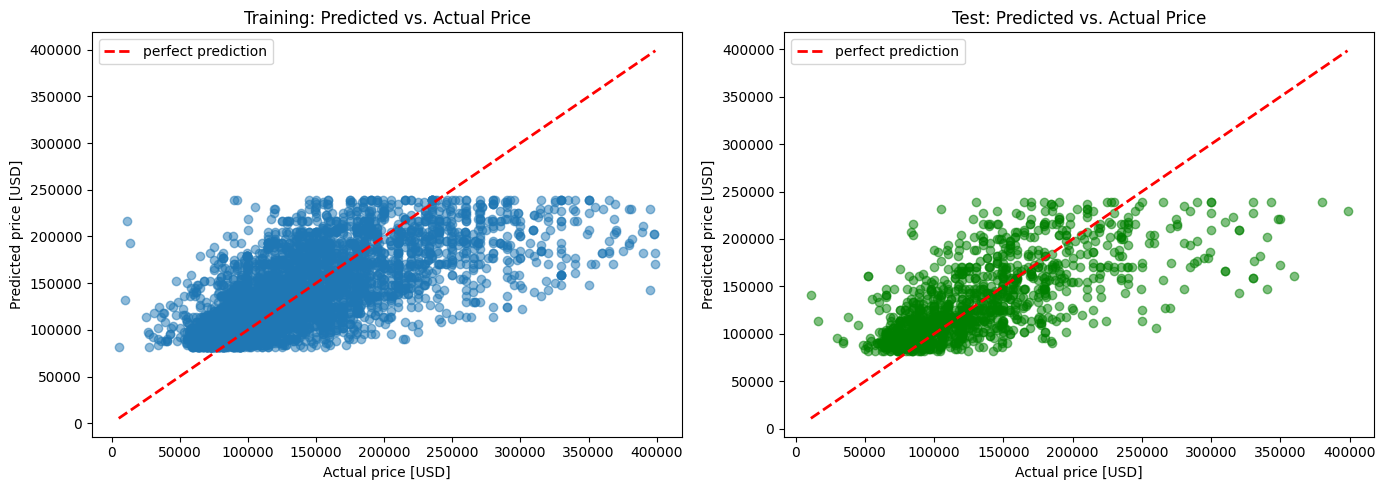

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(14, 5))

# Training set (y_pred_train against y_train)
ax[0].scatter(y_train, y_pred_train, alpha=0.5)
ax[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],'r--', lw=2, label="perfect prediction")
ax[0].set_xlabel("Actual price [USD]")
ax[0].set_ylabel("Predicted price [USD]")
ax[0].set_title("Training: Predicted vs. Actual Price")
ax[0].legend()

# Test set (y_pred_test against y_test)
ax[1].scatter(y_test, y_pred_test, alpha=0.5, color="green")
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="perfect prediction")
ax[1].set_xlabel("Actual price [USD]")
ax[1].set_ylabel("Predicted price [USD]")
ax[1].set_title("Test: Predicted vs. Actual Price")
ax[1].legend()

fig.tight_layout()

### 5.3 Residual Analysis

A **residual** is the difference between the actual value and the model's prediction:

If the model predicted $280,000 but the actual price was $320,000, the residual is $+40,000 (positive = underestimated). If it predicted $350,000 for a $300,000 apartment, the residual is $-50,000 (negative = overestimated).

**Why residuals matter:**

Residual plots reveal patterns that aggregate metrics like MAE and RMSE hide. A model might have an acceptable average error while still systematically underestimating expensive apartments or overestimating cheap ones. Those systematic errors indicate that the model is missing an important relationship in the data.

**The ideal residual plot:** Residuals randomly scattered around zero with no discernible pattern — just noise. This means the model has captured all the systematic structure and the remaining errors are unpredictable.

> **Interpreting Residual Plots**
>
> **Good pattern:** Residuals randomly scattered around zero — no curve, no funnel, no systematic trend. This is what we are hoping to see.
>
> **Bad pattern — curved residuals:** ***The residuals form a curve (high for small and large predicted values, low in the middle, or vice versa).*** This indicates a **non-linear relationship** that a linear model cannot capture. Consider adding polynomial features or using a non-linear model.
>
> **Bad pattern — funnel shape (heteroscedasticity):** ***The spread of residuals increases as predicted values increase.*** For expensive apartments, the model's errors are much larger in absolute terms than for cheap apartments. This is common in price prediction data: a 10% pricing error on a $100,000 apartment ($10,000) is in the same proportional range as a 10% error on a $400,000 apartment ($40,000), but the absolute difference is four times larger.
>
> Heteroscedasticity violates a key assumption of OLS: that errors have constant variance. It means that confidence intervals around predictions are unreliable — they may be too narrow for expensive apartments and too wide for cheap ones. We will revisit this in Lesson 4.
>
> **Bad pattern — systematic bias:** ***Residuals are consistently positive (model always underestimates) or consistently negative (model always overestimates).*** This suggests the model's functional form is wrong — it is not the right type of equation for this relationship.

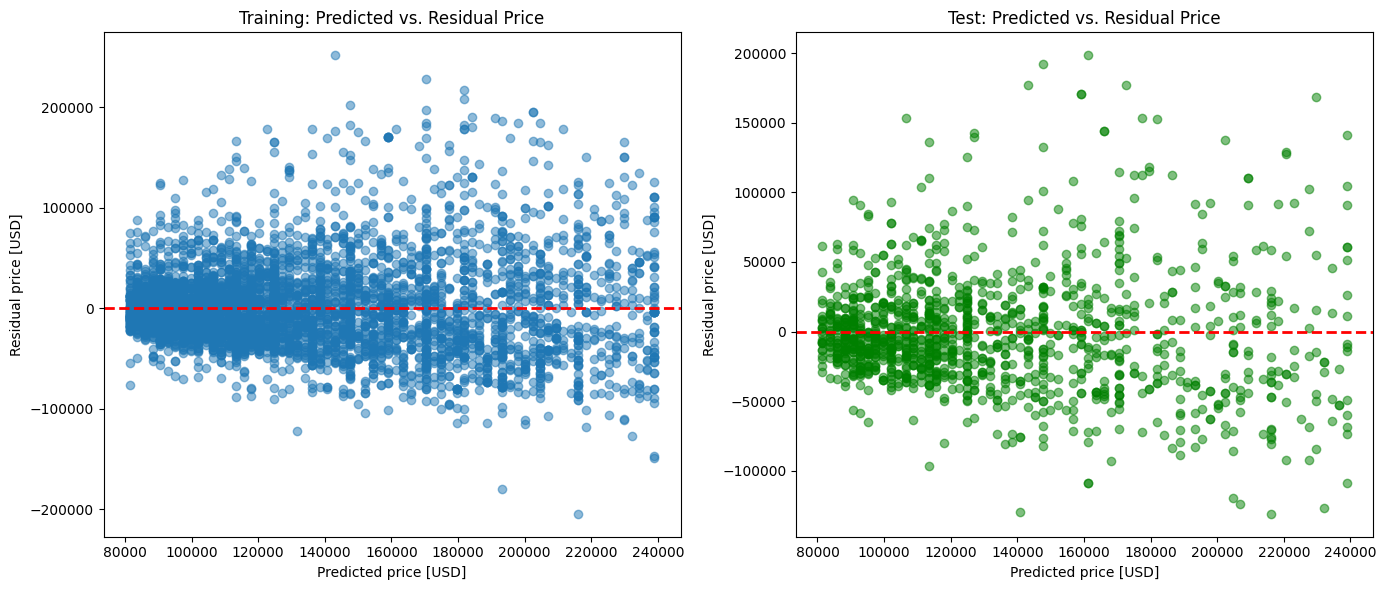

In [ ]:
# Calculate the residuals
y_train_residual = y_train - y_pred_train
y_test_residual = y_test - y_pred_test

# plot the figure
fig, ax = plt.subplots(1,2,figsize=(14,6))

# Train set (y_train_residual against y_pred_train)
ax[0].scatter(y_pred_train, y_train_residual, alpha=0.5)
ax[0].axhline(y=0,lw=2, color='r', linestyle='--')
ax[0].set_xlabel("Predicted price [USD]")
ax[0].set_ylabel("Residual price [USD]")
ax[0].set_title("Training: Predicted vs. Residual Price")

# Test set (y_test_residual against y_pred_test)
ax[1].scatter(y_pred_test, y_test_residual, alpha=0.5, color="green")
ax[1].axhline(y=0,lw=2, color='r', linestyle='--')
ax[1].set_xlabel("Predicted price [USD]")
ax[1].set_ylabel("Residual price [USD]")
ax[1].set_title("Test: Predicted vs. Residual Price")

fig.tight_layout()

### 5.4 Line of Best Fit

The final visualization places the model's predictions as a line over the original scatter plot — this is the "line of best fit" that linear regression has learned from the training data.

**What the line shows:** For every possible value of `surface_covered_in_m2`, the line shows the model's predicted price. The slope of the line is the coefficient $\beta_1$; the y-intercept is $\beta_0$.

**What to notice:** How well does the line thread through the cloud of points? Are there systematic deviations (e.g., does the line overestimate for very small apartments and underestimate for large ones)? A perfect linear fit would have all points balanced symmetrically around the line.

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


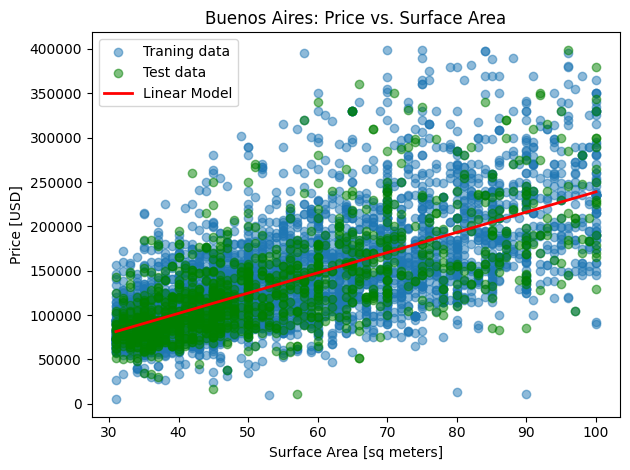

In [ ]:
fig, ax = plt.subplots()

# intstantiante the scatter for train and test sets
ax.scatter(X_train, y_train, alpha=0.5, label="Traning data")
ax.scatter(X_test, y_test,alpha=0.5, color="green", label="Test data")

# create an evenly spaced x values for the line
x_line = np.linspace(X_train.min(),X_train.max(),100).reshape(-1,1)
ax.plot(x_line,model_lr.predict(x_line), color="red", lw=2, label="Linear Model")

ax.set_xlabel("Surface Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Buenos Aires: Price vs. Surface Area")
ax.legend()

fig.tight_layout()